About Me!

Name - Srividhya S Date - 01/03/2026 Id no - IITP_AIMLTN_2601051
Title - The EDA Checklist - Subjective

In [19]:
import pandas as pd
import numpy as np

np.random.seed(42)

n = 200

data = {
    "order_id": range(1001, 1001 + n),
    "city": np.random.choice(["Mumbai", "Delhi", "Bangalore", "Chennai"], size=n),
    "category": np.random.choice(["Electronics", "Clothing", "Groceries", "Furniture"], size=n),
    "order_value": np.random.randint(200, 5000, size=n).astype(float),
    "delivery_days": np.random.randint(1, 15, size=n).astype(float),
    "rating": np.random.choice([1, 2, 3, 4, 5, None], size=n)
}

missing_indices_order = np.random.choice(n, size=15, replace=False)
missing_indices_delivery = np.random.choice(n, size=10, replace=False)
data["order_value"][missing_indices_order] = np.nan
data["delivery_days"][missing_indices_delivery] = np.nan

data["order_value"][5] = 95000
data["order_value"][88] = 87000

df = pd.DataFrame(data)
print(df.shape)
df.head()


(200, 6)


,order_id,city,category,order_value,delivery_days,rating
0,1001,Bangalore,Groceries,4191.0,11.0,4
1,1002,Chennai,Furniture,4923.0,12.0,1
2,1003,Mumbai,Groceries,4882.0,13.0,2
3,1004,Bangalore,Electronics,1848.0,13.0,1
4,1005,Bangalore,Furniture,1645.0,12.0,1


```
Task 1 — Inspect & Handle Missing Values
1)Print the shape of the DataFrame (number of rows and columns).
2)Display the data types of all columns.
3)Count the number of missing values in each column.
4)Calculate the percentage of missing values for each column, rounded to 2 decimal places.
Hint: Percentage = (missing count / total rows) * 100```

In [20]:
print("Shape of DataFrame:", df.shape)
print("\tData Types:\n")
print(df.dtypes)
print("\n\tMissing values per column:")
print(df.isnull().sum())
missing_percent = (df.isnull().sum() / len(df)) * 100
print("\n\tMissing Percentage:\n")
print(missing_percent.round(2))

Shape of DataFrame: (200, 6)
	Data Types:

order_id           int64
city              object
category          object
order_value      float64
delivery_days    float64
rating            object
dtype: object

	Missing values per column:
order_id          0
city              0
category          0
order_value      14
delivery_days    10
rating           32
dtype: int64

	Missing Percentage:

order_id          0.0
city              0.0
category          0.0
order_value       7.0
delivery_days     5.0
rating           16.0
dtype: float64


```
Task 2 — Summarize & Visualize
1)Use df.describe() to generate a summary of all numerical columns. In a markdown cell below the output, write two observations from the summary (for example: which column has the highest mean, or which column shows a large gap between its max and 75th percentile).
2)Plot a histogram for the order_value column to visualize its distribution.
3)Plot a box plot for the delivery_days column to inspect for outliers.
```

In [21]:
print("\tDescribe : \n")
df.describe()


	Describe : 



,order_id,order_value,delivery_days
count,200.000000,186.000000,190.000000
mean,1100.500000,3707.134409,7.810526
std,57.879185,9238.438378,4.075465
min,1001.000000,204.000000,1.000000
25%,1050.750000,1512.000000,4.000000
50%,1100.500000,2934.000000,8.000000
75%,1150.250000,3987.500000,12.000000
max,1200.000000,95000.000000,14.000000


```
Observations:

1. The order_value column got a very large maximum value compared to the 75th percentile, possible outliers.
2. The delivery_days column has a relatively small range, suggesting most deliveries occur within a similar time window.
3. order_value has a stark difference between 75th percentile and maximum.
```

```
Histogram prerequisites
Using 20 bins to divide the order_value range into 20 intervals.
This helps visualize how the order values are distributed across different ranges.
Using figure size (6,4) is chosen to make the plot clearly readable.
```

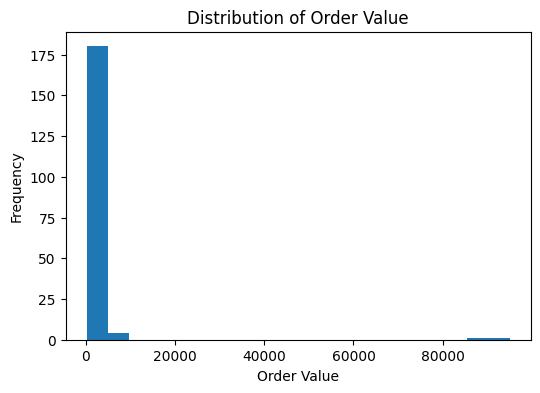

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.hist(df["order_value"], bins=20)

plt.title("Distribution of Order Value")
plt.xlabel("Order Value")
plt.ylabel("Frequency")

plt.show()

We have 200 entries. We can see most of the entries fall within the 0-20,000 slab itself, because our range was less than 5,000. We have specifically added outliers 970,870,000, and that is the reason why we have the bar extended up to 80,000.

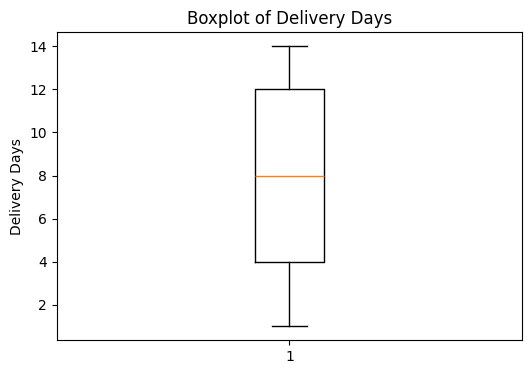

In [23]:
plt.figure(figsize=(6,4))

plt.boxplot(df["delivery_days"].dropna())

plt.title("Boxplot of Delivery Days")
plt.ylabel("Delivery Days")

plt.show()

```
Task 3 — Correlation Analysis
1)Compute the correlation matrix for all numerical columns using df.corr().
2)Plot a heatmap of the correlation matrix with annotation values visible inside each cell.
3)In a markdown cell, write one observation from the heatmap — identify any two columns that appear to have a notable positive or negative relationship.
```

In [24]:
corr_matrix = df.corr(numeric_only=True)
print(corr_matrix)

               order_id  order_value  delivery_days
order_id       1.000000    -0.095503       0.004858
order_value   -0.095503     1.000000       0.141660
delivery_days  0.004858     0.141660       1.000000


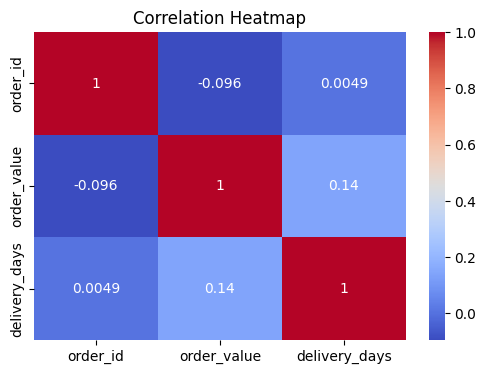

In [25]:
import seaborn as sns

plt.figure(figsize=(6,4))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")

plt.title("Correlation Heatmap")

plt.show()

```
Observation 0:

There appears to be a weak correlation between order_value and delivery_days, suggesting that higher value orders do not necessarily take longer to deliver.

Observation 1:
The maximum value of order_value is much larger than the 75th percentile, indicating the presence of extreme outliers.

Observation 2:
The histogram shows a right-skewed distribution where most order values are clustered in a lower range, while a few very large values extend the distribution.
```